---
tags: [integration, optimization, variational]
---

# OMMX Quantum Benchmarksの活用: Qamomileによる量子アルゴリズムの実装とベンチマーク

本チュートリアルでは、公開ベンチマークデータセットの問題にQamomileの量子アルゴリズムを適用し、その解の品質を同じワークフロー上で古典ソルバーと比較する方法を示します。

**目標:** QamomileでQAOAソルバーを構築し、[OMMX Quantum Benchmarks](https://jij-inc.github.io/OmmxQuantumBenchmarks/ja/)データセットからロードしたLow Autocorrelation Binary Sequences (LABS)インスタンスに対して実行し、[`ommx-pyscipopt-adapter`](https://ommx-ja-book.readthedocs.io/ja/latest/user_guide/supported_ommx_adapters.html)経由で利用できる古典ソルバーSCIPと結果を比較します。QAOA側とSCIP側はどちらも*同じ*`ommx.v1.Instance`を入力とするため、主な違いはアルゴリズムそのものです。そのため直接比較できます。

In [1]:
# 本チュートリアルで追加で必要なパッケージのインストール
# !pip install "qamomile[qiskit]" ommx-quantum-benchmarks ommx-pyscipopt-adapter

In [2]:
import os
import time

# `ommx-quantum-benchmarks`は内部で`minto`を使用しており、`minto`は
# 既定で実験開始時にホスト環境の情報(Pythonバージョン、仮想環境のパスなど)を
# 標準出力に書き出します。レンダリングされたノートブック出力にローカル環境の
# 情報が漏れないよう、ここで抑制しておきます。
os.environ["MINTO_TESTING"] = "true"

import matplotlib.pyplot as plt
import numpy as np
import ommx.v1
import ommx_pyscipopt_adapter
from ommx_quantum_benchmarks.qoblib import Labs
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.optimization.binary_model import BinaryModel, VarType
from qamomile.qiskit import QiskitTranspiler
from qamomile.qiskit.transpiler import QiskitExecutor

## OMMX Quantum Benchmarksとは?

**OMMX**([Open Mathematical prograMming eXchange](https://jij-inc.github.io/ommx/en/introduction.html))は、数理最適化問題をツール間で受け渡すためのデータフォーマットです。`ommx.v1.Instance`には目的関数、制約条件、決定変数のメタデータが格納されます。

**OMMX Quantum Benchmarks**は、この`ommx.v1.Instance`形式で配布される最適化ベンチマークインスタンス集です。最初に提供されているデータセットは**QOBLIB**(Quantum Optimization Benchmarking Library)[arXiv:2504.03832](https://arxiv.org/abs/2504.03832)で、近年の量子最適化研究で使われている9つの問題ファミリーを収録しています。LABS、Market Split、Independent Set、Steiner Tree Packingなどが含まれます。

各ベンチマークインスタンスは`ommx.v1.Instance`として表現されるため、`QAOAConverter`を含む`ommx.v1.Instance`対応のQamomileワークフローは、追加の実装なしにこれらの問題を扱えます。さらに、参照解も`ommx.v1.Solution`形式で含まれており、ベンチマークの評価に使用できます。同じ`Instance`は`ommx-pyscipopt-adapter`のような古典側のOMMXアダプタにも渡せるので、1つの問題定義を量子・古典の両方のワークフローで使えます。

## 問題: Low Autocorrelation Binary Sequences (LABS)

**LABS**は、$\boldsymbol{s} = (s_0, s_1, \dots, s_{n-1}) \in \{-1, +1\}^n$というバイナリ系列のうち、非対角の自己相関

$$
c_k(\boldsymbol{s}) = \sum_{i=0}^{n-k-1} s_i \, s_{i+k},
\qquad k = 1, 2, \dots, n-1
$$

をできるだけ0に近づけるものを求める問題です。ベンチマークの目的関数は**自己相関の二乗和**

$$
E(\boldsymbol{s}) = \sum_{k=1}^{n-1} c_k(\boldsymbol{s})^2,
$$

であり、これを*最小化*します。LABSはNP-hardであり、古典・量子の両方のヒューリスティクスのストレステストとして長く使われてきました。

### LABSインスタンスのロード

`Labs`は2つのモデルを公開しています。一つは`"integer"`($c_k$を整数決定変数として導入し、それらを$\boldsymbol{s}$と結びつける制約を加える形式)、もう一つは`"quadratic_unconstrained"`(積$x_i x_{i+k+1}$を表す補助バイナリ変数$z_{i,k}$を2次のペナルティで導入したQUBO定式化)です。QAOAにはQUBO形式が自然に対応するため、本チュートリアルでは後者を使用します。

In [3]:
dataset = Labs()
print(f"Dataset:           {dataset.name}")
print(f"Available models:  {dataset.model_names}")
print(f"Instance count:    {len(dataset.available_instances['quadratic_unconstrained'])}")
print(f"First 5 instances: {dataset.available_instances['quadratic_unconstrained'][:5]}")

Dataset:           02_labs
Available models:  ['integer', 'quadratic_unconstrained']
Instance count:    99
First 5 instances: ['labs002', 'labs003', 'labs004', 'labs005', 'labs006']


ここでは$n=5$のインスタンスである`labs005`を選びます。このQUBO定式化では合計$n + n(n-1) = 25$個のバイナリ変数(5個の系列ビット$x_i$と$n(n-1) = 20$個の補助$z_{i,k}$)を使います。`Instance.to_qubo()`がペナルティ項を目的関数に畳み込み、未使用変数を取り除くと、15量子ビットの問題になります。ローカルでシミュレートできる程度に小さく、かつQAOAとして非自明なサイズです。

In [4]:
instance, reference_solution = dataset("quadratic_unconstrained", "labs005")
n = 5

print(f"OMMX variables:    {instance.num_variables}")
print(f"OMMX constraints:  {instance.num_constraints}")
print(f"Reference E(s):    {reference_solution.objective}")
print(f"Reference feasible: {reference_solution.feasible}")

OMMX variables:    25
OMMX constraints:  0
Reference E(s):    2.0
Reference feasible: True


同梱の参照解から、$n=5$における既知の最適値が$E^\star = 2$であることが分かります。QAOAとSCIPの結果はこの値と比較していきます。

## アルゴリズム: QAOA

ここでは高レベルの`QAOAConverter`を使わず、[QAOA for MaxCut: Building the Circuit from Scratch](../algorithm/qaoa_maxcut)と同じレシピに従って`@qkernel`でQAOAワークフローを一から構築します。各ゲートの導出はそちらのチュートリアルに任せ、ここでは実装に焦点を当てます。

### OMMXインスタンスからスピンモデルを作る

`Instance.to_qubo()`はペナルティ形式の`ommx.v1.Instance`をQUBOに変換します。続いて`BinaryModel`にラップし、QAOAのコストレイヤーが想定するスピン(-1/+1)領域に変換します。また、エネルギースケールを実行間で揃えるため、係数を正規化します。

In [5]:
# `Instance.to_qubo()`はインスタンスをmutateする(ペナルティ法で制約を目的関数に畳み込む)。
# 呼び出し元のインスタンスを保つために、bytes経由でラウンドトリップさせる。
instance_for_qubo = ommx.v1.Instance.from_bytes(instance.to_bytes())
qubo, qubo_constant = instance_for_qubo.to_qubo()
spin_model = (
    BinaryModel.from_qubo(qubo, qubo_constant)
    .change_vartype(VarType.SPIN)
    .normalize_by_abs_max()
)
print(f"QAOA qubits: {spin_model.num_bits}")

QAOA qubits: 15


### コストハミルトニアン

最適化に「ショット推定」ではなく「厳密な期待値」を用いるため、スピンモデルの係数からIsing型のコストハミルトニアンを直接構築します。線形項は$Z_i$、2次項は$Z_i Z_j$に対応します。

In [6]:
cost_hamiltonian = qm_o.Hamiltonian()
for i, hi in spin_model.linear.items():
    if abs(hi) > 1e-12:
        cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)
for (i, j), Jij in spin_model.quad.items():
    if abs(Jij) > 1e-12:
        cost_hamiltonian.add_term(
            (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
            Jij,
        )
cost_hamiltonian.constant = spin_model.constant

### QAOAのqkernel

ansatzには、一様重ね合わせ、コストレイヤー、ミキサーレイヤーの3つの小さなqkernelを使います。これらを組み合わせて状態準備のための`qaoa_state`を作り、さらに2通りにラップします。1つは`qmc.expval`を使う最適化時の期待値計算のための`qaoa_expval`、もう1つは`qmc.measure`を使う最終ヒストグラム用のサンプリングのための`qaoa_sampling`です。

In [7]:
@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q


@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q


@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q


@qmc.qkernel
def qaoa_state(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Qubit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return q


@qmc.qkernel
def qaoa_expval(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    H: qmc.Observable,
) -> qmc.Float:
    q = qaoa_state(p, quad, linear, n, gammas, betas)
    return qmc.expval(q, H)


@qmc.qkernel
def qaoa_sampling(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = qaoa_state(p, quad, linear, n, gammas, betas)
    return qmc.measure(q)

### トランスパイルと最適化

両方のqkernelを$p = 3$でトランスパイルします。期待値用の`expval_executable`は最適化のために使い、サンプリング用の`sampling_executable`は最後にショット分布を取るために使います。オプティマイザーにはコストハミルトニアンの厳密な期待値をAerの`EstimatorV2`プリミティブ経由で渡すので、BFGSの有限差分勾配はサンプリングノイズに乱されません。パラメータの軌跡を再現できるよう、NumPyにシードを設定します。

In [8]:
p = 3
transpiler = QiskitTranspiler()
expval_executable = transpiler.transpile(
    qaoa_expval,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": spin_model.num_bits,
        "H": cost_hamiltonian,
    },
    parameters=["gammas", "betas"],
)
sampling_executable = transpiler.transpile(
    qaoa_sampling,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": spin_model.num_bits,
    },
    parameters=["gammas", "betas"],
)

SEED = 42
executor = QiskitExecutor(
    backend=AerSimulator(seed_simulator=SEED, max_parallel_threads=1),
    estimator=EstimatorV2(),
)

docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
maxiter = 5 if docs_test_mode else 50

rng = np.random.default_rng(SEED)
initial_params = rng.uniform(0, np.pi, 2 * p)

cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    """`params`におけるコストハミルトニアンの厳密な期待値を返す。"""
    gammas = list(params[:p])
    betas = list(params[p:])
    job = expval_executable.run(
        executor,
        bindings={"gammas": gammas, "betas": betas},
    )
    energy = job.result()
    cost_history.append(energy)
    return energy


t0 = time.perf_counter()
res = minimize(
    cost_fn,
    initial_params,
    method="BFGS",
    options={"maxiter": maxiter},
)
qaoa_optimize_time = time.perf_counter() - t0

print(f"Optimized expectation value (normalized): {res.fun:.4f}")
print(f"Function evaluations:                     {res.nfev}")
print(f"Wall time:                                {qaoa_optimize_time:.2f} s")

Optimized expectation value (normalized): 1.9622
Function evaluations:                     385
Wall time:                                17.41 s


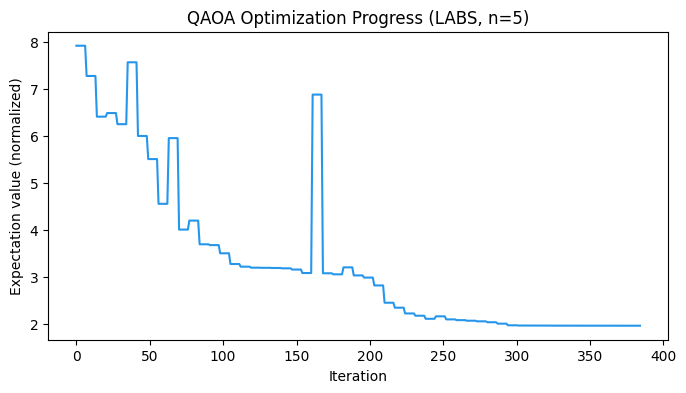

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Expectation value (normalized)")
plt.title("QAOA Optimization Progress (LABS, n=5)")
plt.show()

### 最終サンプリング

最適化されたパラメータでショット数を増やして再度サンプリングします。その後、元の`ommx.v1.Instance`に対してデコードすることで、返ってくる`ommx.v1.SampleSet`から元のQUBO目的関数の値を直接読み取れます。このQUBO定式化では、補助変数$z$が積$x_i x_{i+k+1}$を正しく表現しているサンプルではペナルティが発生せず、目的関数値がLABSエネルギー$E(\boldsymbol{s}) = \sum_k c_k^2$と一致します。一方、$z = x_i x_{i+k+1}$という暗黙の関係を破ったサンプルには、ペナルティが加算されます。

In [10]:
def evaluate_with_ommx(
    sample_result, spin_model: BinaryModel, ommx_instance: ommx.v1.Instance
) -> ommx.v1.SampleSet:
    """SPINサンプルをデコードし、BINARYに変換してOMMXインスタンスで評価する。"""
    spin_ss = spin_model.decode_from_sampleresult(sample_result)
    ommx_samples = ommx.v1.Samples({})
    next_id = 0
    for sample, occ in zip(spin_ss.samples, spin_ss.num_occurrences):
        if occ <= 0:
            continue
        # SPIN (+/-1) -> BINARY (0/1): x = (1 - s) / 2
        binary_state = {idx: (1 - val) // 2 for idx, val in sample.items()}
        sample_ids = list(range(next_id, next_id + occ))
        next_id += occ
        ommx_samples.append(
            sample_ids,
            ommx.v1.State({idx: float(val) for idx, val in binary_state.items()}),
        )
    return ommx_instance.evaluate_samples(ommx_samples)


gammas_opt = list(res.x[:p])
betas_opt = list(res.x[p:])
final_shots = 256 if docs_test_mode else 4096

final_result = sampling_executable.sample(
    executor,
    shots=final_shots,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()
qaoa_sample_set = evaluate_with_ommx(final_result, spin_model, instance)

qaoa_summary = qaoa_sample_set.summary
qaoa_best = qaoa_sample_set.best_feasible
qaoa_best_E = int(round(qaoa_best.objective))
ref_E = int(reference_solution.objective)

print(f"Shots:                {len(qaoa_summary)}")
print(f"QAOA best objective:  {qaoa_best_E}")
print(f"Reference E*:         {ref_E}")

Shots:                4096
QAOA best objective:  2
Reference E*:         2


### 目的関数値の分布

QAOAは一つの解ではなくビット列の分布を返します。下のヒストグラムは、最適化済みパラメータで取得した各ショットのQUBO目的関数の値です。赤の点線は最適値$E^\star$を示します。その線上、またはすぐ右側にあるサンプルは、$x$の値がLABS和を最小化し、$z$の値が積を正しく符号化しています。線から大きく右に離れたサンプルは、$z$の不整合に対するペナルティが加算されています。

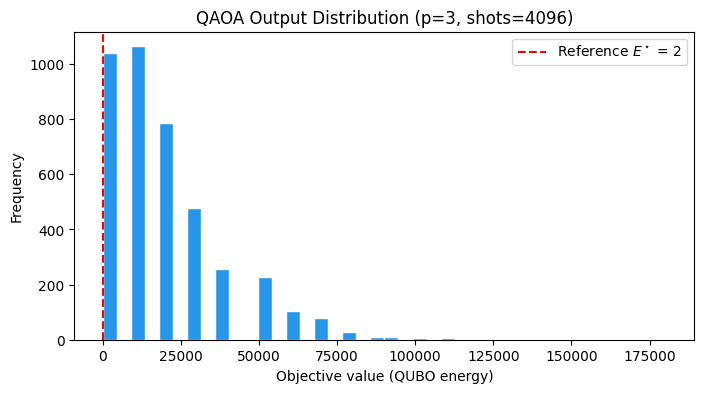

In [11]:
objectives = qaoa_summary["objective"].to_numpy()

plt.figure(figsize=(8, 4))
plt.hist(objectives, bins=40, color="#2696EB", edgecolor="white")
plt.axvline(
    ref_E,
    color="red",
    linestyle="--",
    label=f"Reference $E^\\star$ = {ref_E}",
)
plt.xlabel("Objective value (QUBO energy)")
plt.ylabel("Frequency")
plt.title(f"QAOA Output Distribution (p={p}, shots={final_shots})")
plt.legend()
plt.show()

## 古典ベースライン: OMMXアダプタ経由のSCIP

**SCIP**は分枝限定法ベースのMILP/QUBOソルバーで、厳密解を求めることができます。同じ`ommx.v1.Instance`を`ommx_pyscipopt_adapter.OMMXPySCIPOptAdapter.solve`に渡すと、PySCIPOpt経由で問題がSCIPに渡され、元のインスタンスに対して評価された`ommx.v1.Solution`が返ります。そのため、`.objective`はQAOA側と直接比較できます。

In [12]:
t0 = time.perf_counter()
scip_solution = ommx_pyscipopt_adapter.OMMXPySCIPOptAdapter.solve(instance)
scip_solve_time = time.perf_counter() - t0

scip_E = int(round(scip_solution.objective))
print(f"SCIP E(s):    {scip_E}")
print(f"SCIP feasible: {scip_solution.feasible}")
print(f"Wall time:    {scip_solve_time:.3f} s")

SCIP E(s):    2
SCIP feasible: True
Wall time:    0.425 s


## 結果の比較

SCIPは最適解を決定論的に返します。一方、QAOAはビット列の分布を返します。そこでQAOA側は**ベストショット**(全サンプル中で最も低い目的関数値を達成したビット列)と、参照最適値に対する**ヒット率**(その値を達成したショットの割合)を見てみます。

In [13]:
# ヒット率: 参照最適値を達成したショットの割合
hit_rate = float((qaoa_summary["objective"].round().astype(int) == ref_E).mean())

print(f"{'Solver':<22} {'E(s)':>8} {'Time (s)':>12}")
print("-" * 46)
print(f"{'Reference (bundled)':<22} {ref_E:>8} {'-':>12}")
print(f"{'SCIP (classical)':<22} {scip_E:>8} {scip_solve_time:>12.3f}")
print(f"{'QAOA (best shot)':<22} {qaoa_best_E:>8} {qaoa_optimize_time:>12.2f}")
print()
print(f"QAOA hit rate on E* = {ref_E}: {hit_rate:.1%}  ({final_shots} shots)")

Solver                     E(s)     Time (s)
----------------------------------------------
Reference (bundled)           2            -
SCIP (classical)              2        0.425
QAOA (best shot)              2        17.41

QAOA hit rate on E* = 2: 4.6%  (4096 shots)


このベンチマークから読み取れることは大きく2点あります。

1. **最適値の到達:** SCIPとQAOAベストショットのどちらも参照最適値$E^\star = 2$に到達しており、QAOAは$n = 5$かつ$p = 3$という軽い設定でも最適系列を見つけられることが分かります。
2. **集中度:** QAOAの価値はサンプリング確率を低エネルギーのビット列に集中させる点にあります。上記のヒット率とヒストグラム左端の集中が、その性質を定量化したものです。

なお、経過時間の値はあくまでも参考に留まります。SCIPの計測値はCPU上でのソルバーの実行時間であるのに対し、QAOA側の計測値は状態ベクトルシミュレータ上での古典・量子最適化ループ全体を含み、いずれも実行環境に依存します。このため、実際はより公正な評価方法が必要です。いずれにせよ、OMMX Quantum BenchmarksのようなデータセットとQamomileを組み合わせることで、量子アルゴリズムと古典ソルバーを様々な指標のもとで容易に比較することができます。

## まとめ

本チュートリアルでは次のことを行いました。

1. OMMX Quantum BenchmarksデータセットからLABSインスタンスをそのまま`ommx.v1.Instance`として読み込みました。
2. `Instance.to_qubo()`でQUBOを取り出して`BinaryModel`にラップし、スピン領域に切り替えた上で、`@qkernel`を使った自作のQAOA ansatzを`QiskitTranspiler` + `AerSimulator`を通じて実行しました。
3. QAOAの出力(ベストショット、ヒット率、サンプリング分布)を、同じインスタンスに対する`ommx_pyscipopt_adapter.OMMXPySCIPOptAdapter.solve`の結果、およびベンチマークに同梱された参照最適値と比較しました。

同じパターンは他のQOBLIBデータセット(`Marketsplit`、`IndependentSet`、`Network`など)にも適用できます。対応するデータセットクラスでロードし、`Instance.to_qubo()`でQUBOを取り出して、同じ`BinaryModel` + QAOA ansatz + transpileのループを再利用します。大きなインスタンスがローカルシミュレータの能力を超えた場合は、同じ`executable`をQamomileの他の量子SDK連携(`QuriPartsTranspiler`、`CudaqTranspiler`など)や実機に切り替えられます。